# 03b — Multi-frequency MIDAS (weekly target, daily + monthly) + FRED/COT — Python port

Python/`scipy` port of the R `03b_midas_daily.ipynb` (kept alongside). Weekly W-FRI silver
log-return from a **daily block** (6 cross-asset daily returns × K=20 trading-day lags,
Beta/Almon-weighted, replacing the weekly cross-asset EXOG) + the **monthly macro block**; base =
silver weekly AR lags. Public-info rungs mirror `01_arima`: **FRED_daily** + **COT** enter as
**weekly** regressors (jobless/COT are weekly-released, so they're not put in the daily block).
Restricted weights only. Reuses `eval_utils`; writes `metrics_midas_daily_weekly.csv` etc.
(+ RMSE-best siblings). Full §3a battery incl. always-up line, best-by-RMSE, richer PT.


## Setup

In [1]:
import sys, os
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
sys.path.append('../../src')
from eval_utils import evaluate, period_metrics, diebold_mariano, pesaran_timmermann, oos_r2, PERIODS

DATA = '../../data/processed/'
RAW  = '../../data/raw/'


## 1. Load & aggregate to weekly

In [2]:
train = pd.read_csv(DATA+'train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv(DATA+'val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv(DATA+'test.csv',  index_col=0, parse_dates=True)

TARGET       = 'silver_return'
EXOG_RETURNS = ['gold_return','usd_return','copper_return','sp500_return','vix_return','oil_return']
EXOG_LEVELS  = ['gs_ratio_z']
FRED_DAILY   = ['real_rates_chg','breakeven_chg','jobless_chg']
COT_COLS     = ['cot_mm_net_pct','cot_comm_net_pct']

def to_weekly(df):
    summ = [c for c in [TARGET]+EXOG_RETURNS+FRED_DAILY if c in df.columns]
    last = [c for c in EXOG_LEVELS+COT_COLS         if c in df.columns]
    agg = {c:'sum' for c in summ}; agg.update({c:'last' for c in last})
    return df.resample('W-FRI').agg(agg)

train_w, val_w, test_w = to_weekly(train), to_weekly(val), to_weekly(test)
all_w   = pd.concat([train_w, val_w, test_w]).sort_index()
n_train = len(train_w) + len(val_w)
print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')


Weekly obs — train+val: 417, test: 174


## 2. Base (silver AR) + public-info (FRED/COT weekly) lags

In [3]:
for k in (1,2,3):
    all_w[f'silver_lag{k}'] = all_w['silver_return'].shift(k)
for v in EXOG_LEVELS:
    all_w[f'{v}_lag1'] = all_w[v].shift(1)
# FRED_daily + COT public-info groups as weekly regressors (1-week lag, warmup 0). jobless/COT are
# weekly-released, so these stay weekly (NOT in the daily block, which is the genuinely-daily cross-assets).
for v in FRED_DAILY + COT_COLS:
    if v in all_w.columns:
        all_w[f'{v}_lag1'] = all_w[v].shift(1).fillna(0.0)

AR_LAGS   = [c for c in ['silver_lag1','silver_lag2','silver_lag3'] if c in all_w.columns]
GS_LAGS   = [f'{v}_lag1' for v in EXOG_LEVELS if f'{v}_lag1' in all_w.columns]
FRED_LAGS = [f'{v}_lag1' for v in FRED_DAILY  if f'{v}_lag1' in all_w.columns]
COT_LAGS  = [f'{v}_lag1' for v in COT_COLS    if f'{v}_lag1' in all_w.columns]
print('AR:', AR_LAGS, '| GS:', GS_LAGS, '| FRED:', FRED_LAGS, '| COT:', COT_LAGS)


AR: ['silver_lag1', 'silver_lag2', 'silver_lag3'] | GS: ['gs_ratio_z_lag1'] | FRED: ['real_rates_chg_lag1', 'breakeven_chg_lag1', 'jobless_chg_lag1'] | COT: ['cot_mm_net_pct_lag1', 'cot_comm_net_pct_lag1']


## 3. Daily high-frequency block (cross-asset MIDAS predictors)

In [4]:
daily = pd.concat([train, val, test]).sort_index()
DAILY_VARS = ['gold_return','usd_return','copper_return','sp500_return','vix_return','oil_return']
assert all(v in daily.columns for v in DAILY_VARS)
K_DAILY = 20

def build_weekly_daily_lags(weekly_dates, s, k):
    vals = s.values; obs = ~np.isnan(vals)
    out  = np.full((len(weekly_dates), k), np.nan)
    for i, wd in enumerate(weekly_dates):
        keep = obs & (s.index < wd - pd.Timedelta(days=6))
        past = vals[keep]
        if len(past) >= k:
            out[i] = past[-k:][::-1]
    return out

daily_lags = {v.replace('_return',''): build_weekly_daily_lags(all_w.index, daily[v], K_DAILY) for v in DAILY_VARS}
print('Daily lag matrices:', {v: m.shape for v, m in daily_lags.items()})


Daily lag matrices: {'gold': (591, 20), 'usd': (591, 20), 'copper': (591, 20), 'sp500': (591, 20), 'vix': (591, 20), 'oil': (591, 20)}


### Look-ahead audit — daily block

In [5]:
position_fri = all_w.index - pd.Timedelta(days=7)
for v in DAILY_VARS:
    s = daily[v]; obs = s.notna().values; min_slack = np.inf
    for i, d in enumerate(all_w.index):
        keep = obs & (s.index < d - pd.Timedelta(days=6))
        if keep.any():
            min_slack = min(min_slack, (position_fri[i] - s.index[keep].max()).days)
    assert not (np.isfinite(min_slack) and min_slack < 0), f'look-ahead in daily {v}'
    print(f'  {v.replace("_return",""):8s} OK  (min slack {int(min_slack)} d)')
print('Daily look-ahead audit passed.')


  gold     OK  (min slack 0 d)
  usd      OK  (min slack 0 d)
  copper   OK  (min slack 0 d)
  sp500    OK  (min slack 0 d)
  vix      OK  (min slack 0 d)
  oil      OK  (min slack 0 d)
Daily look-ahead audit passed.


## 4. Monthly macro block — the second frequency

In [6]:
macro = pd.read_csv(RAW+'monthly_macro.csv', index_col=0, parse_dates=True)
MACRO_VARS = ['cpi','fed_funds','ind_prod','m2']
assert all(v in macro.columns for v in MACRO_VARS), 'monthly_macro.csv missing a column'
N_MACRO_LAGS    = 3
MACRO_AVAIL_LAG = {'cpi':46,'ind_prod':48,'fed_funds':35,'m2':30}

def build_weekly_macro_lags(weekly_dates, s, lag_days, n_lags=N_MACRO_LAGS):
    avail = s.index + pd.Timedelta(days=lag_days)
    vals  = s.values; obs = ~np.isnan(vals)
    out   = np.full((len(weekly_dates), n_lags), np.nan)
    for i, d in enumerate(weekly_dates):
        keep = obs & (avail < d - pd.Timedelta(days=6))
        past = vals[keep]
        if len(past) >= n_lags:
            out[i] = past[-n_lags:][::-1]
    return out

macro_lags = {v: build_weekly_macro_lags(all_w.index, macro[v], MACRO_AVAIL_LAG[v]) for v in MACRO_VARS}
print('Macro lag matrices:', {v: m.shape for v, m in macro_lags.items()})


Macro lag matrices: {'cpi': (591, 3), 'fed_funds': (591, 3), 'ind_prod': (591, 3), 'm2': (591, 3)}


### Look-ahead audit — macro

In [7]:
position_fri = all_w.index - pd.Timedelta(days=7)
for v in MACRO_VARS:
    avail = macro.index + pd.Timedelta(days=MACRO_AVAIL_LAG[v]); obs = macro[v].notna().values
    min_slack = np.inf
    for i, d in enumerate(all_w.index):
        keep = obs & (avail < d - pd.Timedelta(days=6))
        if keep.any():
            min_slack = min(min_slack, (position_fri[i] - avail[keep].max()).days)
    assert not (np.isfinite(min_slack) and min_slack < 0), f'look-ahead in {v}'
    print(f'  {v:11s} OK  (min slack {int(min_slack)} d)')
print('Macro look-ahead audit passed.')


  cpi         OK  (min slack 0 d)
  fed_funds   OK  (min slack 0 d)
  ind_prod    OK  (min slack 0 d)
  m2          OK  (min slack 0 d)
Macro look-ahead audit passed.


## 5. Weekly sentiment (lagged 1 week)

In [8]:
sent = pd.read_csv(DATA+'daily_sentiment.csv', index_col=0, parse_dates=True)
sent_cols = [c for c in ['reddit_sentiment','news_sentiment'] if c in sent.columns]
sentiment_available = len(sent_cols) > 0
aligned = sent[sent_cols].resample('W-FRI').mean().reindex(all_w.index)
if 'reddit_sentiment' in sent_cols:
    all_w['reddit_lag1'] = aligned['reddit_sentiment'].ffill().shift(1).fillna(0.0)
if 'news_sentiment' in sent_cols:
    all_w['news_lag1'] = aligned['news_sentiment'].ffill().shift(1).fillna(0.0)
print('Sentiment merged:', [c for c in ['reddit_lag1','news_lag1'] if c in all_w.columns])


Sentiment merged: ['reddit_lag1', 'news_lag1']


## 6. MIDAS weight functions and fitters

In [9]:
def nbeta_w(k, theta):
    th = np.maximum(theta, 0.1)
    x  = k / (k.max() + 1)
    w  = x**(th[0]-1) * (1-x)**(th[1]-1)
    w  = np.maximum(w, 1e-10)
    return w / w.sum()

def nealmon_w(k, theta):
    e = theta[0]*k + theta[1]*k**2
    e = e - e.max()
    w = np.exp(e)
    return w / w.sum()


In [10]:
# Restricted MIDAS only (Beta/Almon): the daily block has 6x20=120 lags, which U-MIDAS would overfit.
def fit_with_midas(y, base_X, macro_list, weight_fn=nbeta_w, start=None, lower=None):
    names = list(macro_list); nmac = len(names)
    klists = {v: np.arange(1, macro_list[v].shape[1]+1) for v in names}
    if start is None: start = np.tile([1.0,5.0], nmac)
    if lower is None: lower = np.full(2*nmac, 0.1)
    base = np.asarray(base_X, float); y = np.asarray(y, float)
    def design(theta):
        cols = [macro_list[v] @ weight_fn(klists[v], theta[2*j:2*j+2]) for j, v in enumerate(names)]
        return np.column_stack([np.ones(len(y)), base, np.column_stack(cols)])
    def obj(theta):
        X = design(theta)
        if not np.all(np.isfinite(X)): return 1e9
        b, *_ = np.linalg.lstsq(X, y, rcond=None)
        r = y - X @ b
        return float(r @ r)
    res = minimize(obj, start, method='L-BFGS-B', bounds=[(lo, None) for lo in lower], options={'maxiter':1000})
    theta = res.x
    weights = {v: weight_fn(klists[v], theta[2*j:2*j+2]) for j, v in enumerate(names)}
    X = design(theta); b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return {'spec':'restricted','weights':weights,'coefs':b,'theta':theta,'names':names,'converged':bool(res.success)}

def predict_with_midas(fit, base_X, macro_list):
    base = np.asarray(base_X, float)
    cols = [macro_list[v] @ fit['weights'][v] for v in fit['names']]
    X = np.column_stack([np.ones(len(base)), base, np.column_stack(cols)])
    return X @ fit['coefs']

def make_mask(y, base_X, mlist):
    m = ~np.isnan(y) & ~np.isnan(np.asarray(base_X, float)).any(axis=1)
    for v in mlist: m = m & ~np.isnan(mlist[v]).any(axis=1)
    return m


## 7. Two-stage protocol — spec selection, then walk-forward ladder
**Stage 1** picks Beta vs Almon by val WDA on the combined multi-frequency list. **Stage 2**
walk-forwards (expanding, refit every 4 weeks). Public-info rungs `EXOG-d+FRED_daily`, `+COT`,
`+FRED_daily+COT` (FRED/COT as weekly regressors); FRED+COT folded into `EXOG-d+ALL`.


In [11]:
y_all  = all_w['silver_return'].values
ar_all = all_w[AR_LAGS].values
idx    = np.arange(len(all_w)); n_train_only = len(train_w)
sub    = lambda rm, ml: {v: ml[v][rm] for v in ml}
mf_all = {**daily_lags, **macro_lags}

mask  = make_mask(y_all, ar_all, mf_all)
m_tr1 = mask & (idx <  n_train_only)
m_v   = mask & (idx >= n_train_only) & (idx < n_train)
kk = len(mf_all)
print(f'Stage 1 — {kk} MIDAS series: {len(daily_lags)} daily + {len(macro_lags)} monthly')
fits1 = {
  'Beta-MIDAS':  fit_with_midas(y_all[m_tr1], ar_all[m_tr1], sub(m_tr1, mf_all), nbeta_w,  np.tile([1.,5.],kk), np.full(2*kk, 0.1)),
  'Almon-MIDAS': fit_with_midas(y_all[m_tr1], ar_all[m_tr1], sub(m_tr1, mf_all), nealmon_w, np.tile([0.,0.],kk), np.full(2*kk, -5.0)),
}
s1 = [evaluate(nm, y_all[m_v], predict_with_midas(ft, ar_all[m_v], sub(m_v, mf_all))) for nm, ft in fits1.items()]
best_spec = max(s1, key=lambda r: r['wda'])['model']
print('=> winner by val WDA:', best_spec)
pd.DataFrame(s1).to_csv(DATA+'midas_daily_stage1_specs.csv', index=False)

# ── Stage 2 ──────────────────────────────────────────────────────────────────
RETRAIN_EVERY = 4
ar_F = ar_all[mask]; gs_F = all_w[GS_LAGS].values[mask]
fred_F = all_w[FRED_LAGS].values[mask]; cot_F = all_w[COT_LAGS].values[mask]
daily_F = sub(mask, daily_lags); macro_F = sub(mask, macro_lags)
dates_F = all_w.index[mask]; orig = idx[mask]; test_pos = np.where(orig >= n_train)[0]
y_F = y_all[mask]; y_te = y_F[test_pos]; dates_te = dates_F[test_pos]
if sentiment_available:
    r_F = all_w['reddit_lag1'].values[mask]; n_F = all_w['news_lag1'].values[mask]

def fit_restricted(y, baseX, mlist):
    k = len(mlist)
    if best_spec == 'Beta-MIDAS': return fit_with_midas(y, baseX, mlist, nbeta_w,  np.tile([1.,5.],k), np.full(2*k, 0.1))
    return fit_with_midas(y, baseX, mlist, nealmon_w, np.tile([0.,0.],k), np.full(2*k, -5.0))

def walk_forward(baseX, mlist):
    preds = np.full(len(test_pos), np.nan); fit = None
    for j, p in enumerate(test_pos):
        if j % RETRAIN_EVERY == 0:
            fit = fit_restricted(y_F[:p], baseX[:p], {v: mlist[v][:p] for v in mlist})
        preds[j] = predict_with_midas(fit, baseX[p:p+1], {v: mlist[v][p:p+1] for v in mlist})[0]
    return preds

all_preds = {}; all_results = []
def run_variant(label, baseX, mlist):
    all_preds[label] = walk_forward(baseX, mlist)
    all_results.append(evaluate(label, y_te, all_preds[label]))

all_preds['Naive (t-1 week)'] = np.concatenate([[np.nan], y_te[:-1]])
all_results.append(evaluate('Naive (t-1 week)', y_te, all_preds['Naive (t-1 week)']))
all_preds['Drift (prevailing mean)'] = np.array([y_F[:p].mean() for p in test_pos])
all_results.append(evaluate('Drift (prevailing mean)', y_te, all_preds['Drift (prevailing mean)']))

run_variant('EXOG-d',       ar_F, daily_F)
run_variant('EXOG-d+Macro', ar_F, {**daily_F, **macro_F})
if len(GS_LAGS):
    run_variant('EXOG-d+GS', np.column_stack([ar_F, gs_F]), daily_F)
run_variant('EXOG-d+FRED_daily',     np.column_stack([ar_F, fred_F]),        daily_F)
run_variant('EXOG-d+COT',            np.column_stack([ar_F, cot_F]),         daily_F)
run_variant('EXOG-d+FRED_daily+COT', np.column_stack([ar_F, fred_F, cot_F]), daily_F)
if sentiment_available:
    run_variant('EXOG-d+Reddit',          np.column_stack([ar_F, r_F]),      daily_F)
    run_variant('EXOG-d+News',            np.column_stack([ar_F, n_F]),      daily_F)
    run_variant('EXOG-d+Reddit+News',     np.column_stack([ar_F, r_F, n_F]), daily_F)
    run_variant('EXOG-d+Macro+Sentiment', np.column_stack([ar_F, r_F, n_F]), {**daily_F, **macro_F})
    if len(GS_LAGS):
        run_variant('EXOG-d+GS+Sentiment', np.column_stack([ar_F, gs_F, r_F, n_F]), daily_F)
        run_variant('EXOG-d+ALL', np.column_stack([ar_F, gs_F, fred_F, cot_F, r_F, n_F]), {**daily_F, **macro_F})

L = test_pos[-1] + 1; mfL = {**daily_F, **macro_F}
fit_em = fit_restricted(y_F[:L], ar_F[:L], {v: mfL[v][:L] for v in mfL})


Stage 1 — 10 MIDAS series: 6 daily + 4 monthly
Beta-MIDAS                                     RMSE=0.05070  MAE=0.04125  DA=0.481  WDA=0.441
Almon-MIDAS                                    RMSE=0.05001  MAE=0.04137  DA=0.385  WDA=0.448
=> winner by val WDA: Almon-MIDAS
Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03713  DA=0.557  WDA=0.588
EXOG-d                                         RMSE=0.05268  MAE=0.03829  DA=0.506  WDA=0.514
EXOG-d+Macro                                   RMSE=0.05343  MAE=0.03915  DA=0.443  WDA=0.481
EXOG-d+GS                                      RMSE=0.05132  MAE=0.03694  DA=0.552  WDA=0.585
EXOG-d+FRED_daily                              RMSE=0.05253  MAE=0.03781  DA=0.517  WDA=0.582
EXOG-d+COT                                     RMSE=0.05261  MAE=0.03791  DA=0.523  WDA=0.561
EXOG-d+FRED_daily+COT                          RMSE=0.05308  MAE=0.03793 

## 8. Results table

In [12]:
metrics_df = pd.DataFrame(all_results)
drift_p = all_preds['Drift (prevailing mean)']
metrics_df['oos_r2'] = [oos_r2(y_te, all_preds[m], drift_p) for m in metrics_df['model']]
metrics_df.to_csv(DATA+'metrics_midas_daily_weekly.csv', index=False)
print(metrics_df.round(6).to_string(index=False))


                  model     rmse      mae  dir_acc      wda    oos_r2
       Naive (t-1 week) 0.075941 0.053966 0.491329 0.489862 -1.129014
Drift (prevailing mean) 0.051897 0.037132 0.557471 0.587779  0.000000
                 EXOG-d 0.052676 0.038293 0.505747 0.513729 -0.030250
           EXOG-d+Macro 0.053435 0.039148 0.442529 0.480811 -0.060151
              EXOG-d+GS 0.051319 0.036943 0.551724 0.584620  0.022160
      EXOG-d+FRED_daily 0.052530 0.037815 0.517241 0.582160 -0.024549
             EXOG-d+COT 0.052609 0.037909 0.522989 0.561008 -0.027641
  EXOG-d+FRED_daily+COT 0.053080 0.037927 0.534483 0.571755 -0.046113
          EXOG-d+Reddit 0.052817 0.038364 0.494253 0.527659 -0.035756
            EXOG-d+News 0.053249 0.038454 0.511494 0.525130 -0.052783
     EXOG-d+Reddit+News 0.052734 0.038377 0.494253 0.510723 -0.032521
 EXOG-d+Macro+Sentiment 0.053486 0.039078 0.505747 0.532144 -0.062163
    EXOG-d+GS+Sentiment 0.051756 0.037177 0.534483 0.529817  0.005437
             EXOG-d+

### Always-up directional benchmark

In [13]:
print('Always-up WDA by period (directional benchmark to beat):')
_s = pd.Series(y_te, index=dates_te)
for lbl, (a, b) in PERIODS.items():
    sub_ = _s.loc[a:b]
    if len(sub_) < 4: continue
    au = np.sum(np.abs(sub_.values) * (sub_.values > 0)) / np.sum(np.abs(sub_.values))
    print(f'  {lbl:22s} always-up WDA = {au:.3f}  (n={len(sub_)})')


Always-up WDA by period (directional benchmark to beat):
  2023  (choppy)         always-up WDA = 0.492  (n=52)
  2024  (bull start)     always-up WDA = 0.570  (n=52)
  2025  (bull run)       always-up WDA = 0.757  (n=52)
  2026  (YTD)            always-up WDA = 0.498  (n=18)
  ── Full test ──        always-up WDA = 0.588  (n=174)


## 9. Fitted lag-weight profiles (EXOG-d+Macro)

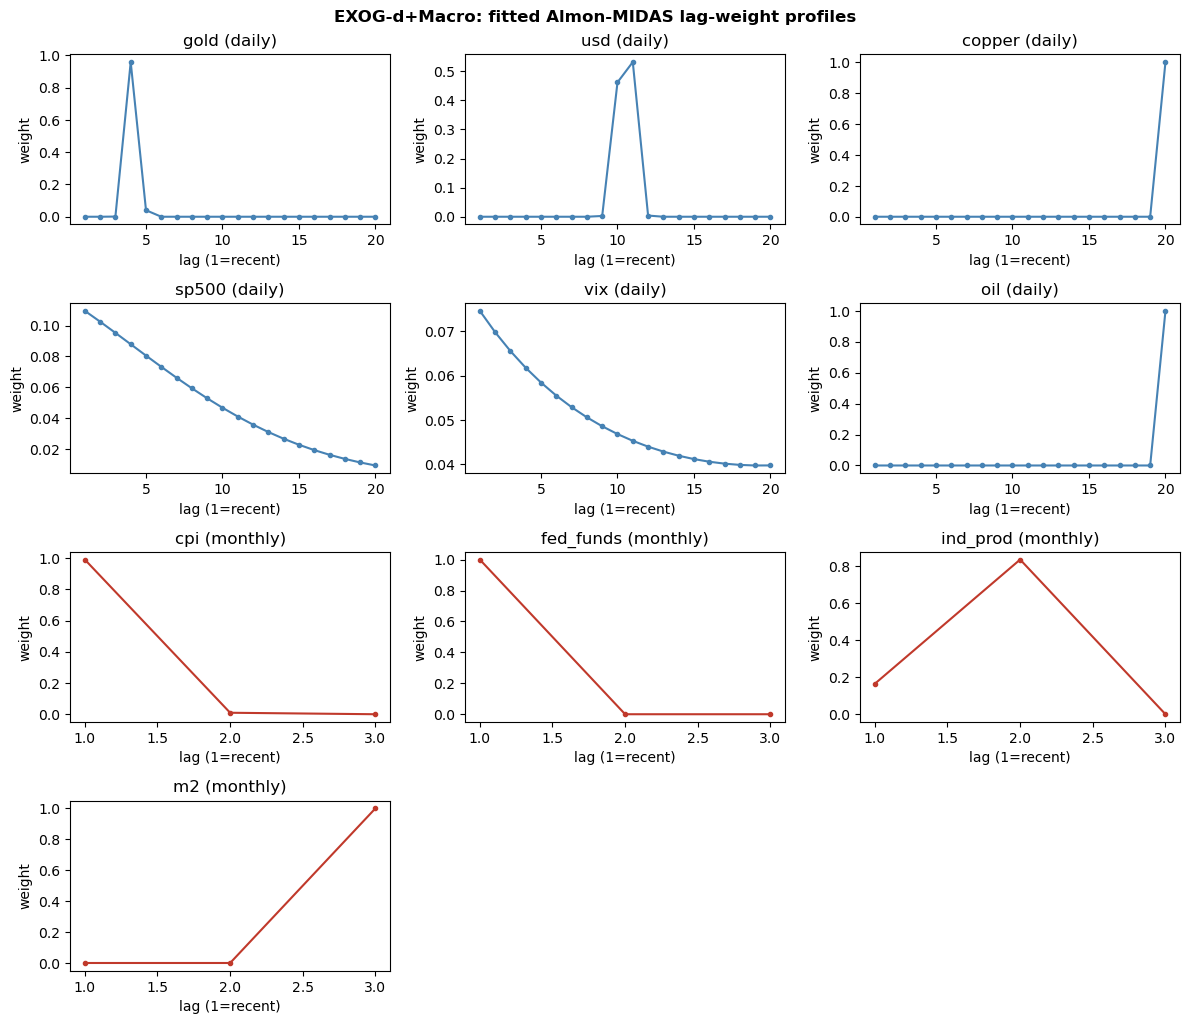

In [14]:
ws = fit_em['weights']; vs = list(ws); ncol = 3; nrow = int(np.ceil(len(vs)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 2.6*nrow)); axes = np.atleast_1d(axes).ravel()
for ax, v in zip(axes, vs):
    w = ws[v]; col = 'steelblue' if len(w) > 5 else '#c0392b'
    ax.plot(range(1, len(w)+1), w, '-o', ms=3, color=col)
    ax.set_title(f'{v} ({"daily" if len(w)>5 else "monthly"})'); ax.set_xlabel('lag (1=recent)'); ax.set_ylabel('weight')
for ax in axes[len(vs):]: ax.axis('off')
fig.suptitle(f'EXOG-d+Macro: fitted {best_spec} lag-weight profiles', fontweight='bold')
plt.tight_layout(); plt.show()


## 10. Period breakdown — best by WDA *and* by RMSE

In [15]:
cand = metrics_df[~metrics_df['model'].isin(['Naive (t-1 week)','Drift (prevailing mean)'])]
best_wda  = cand.loc[cand['wda'].idxmax(),  'model']
best_rmse = cand.loc[cand['rmse'].idxmin(), 'model']
print(f'Best by WDA: {best_wda}   |   Best by RMSE: {best_rmse}')
for tag, bn, fper, fpred in [('WDA',  best_wda,  'period_midas_daily_weekly.csv',      'preds_midas_daily_best_weekly.csv'),
                             ('RMSE', best_rmse, 'period_midas_daily_rmse_weekly.csv', 'preds_midas_daily_bestrmse_weekly.csv')]:
    bp = all_preds[bn]
    pp = period_metrics(np.asarray(y_te), np.asarray(bp), dates_te, PERIODS)
    pp.to_csv(DATA+fper)
    pd.DataFrame({'Date': dates_te, 'actual': y_te, 'predicted': bp}).to_csv(DATA+fpred, index=False)
    print(f'\n[{tag}-best = {bn}]'); print(pp.round(3))
best_name, best_pred = best_wda, all_preds[best_wda]


Best by WDA: EXOG-d+ALL   |   Best by RMSE: EXOG-d+GS

[WDA-best = EXOG-d+ALL]
                      n   RMSE    MAE     DA    WDA
Period                                             
2023  (choppy)       52  0.039  0.031  0.500  0.568
2024  (bull start)   52  0.037  0.029  0.692  0.761
2025  (bull run)     52  0.054  0.039  0.423  0.439
2026  (YTD)          18  0.101  0.079  0.667  0.607
── Full test ──     174  0.053  0.038  0.552  0.586

[RMSE-best = EXOG-d+GS]
                      n   RMSE    MAE     DA    WDA
Period                                             
2023  (choppy)       52  0.040  0.032  0.481  0.559
2024  (bull start)   52  0.037  0.029  0.577  0.694
2025  (bull run)     52  0.051  0.035  0.596  0.524
2026  (YTD)          18  0.098  0.079  0.556  0.575
── Full test ──     174  0.051  0.037  0.552  0.585


## 11. Significance tests
Primary DM-vs-Drift floor (se + ae) + OOS R²; secondary incremental vs `EXOG-d`, and
Pesaran-Timmermann (per-variant + multiple-testing summary + per-period for the best variant).


In [16]:
drift_p = all_preds['Drift (prevailing mean)']
print('Floor test — each variant vs Drift   [primary]'); print('-'*92)
for nm in all_preds:
    if nm in ('Drift (prevailing mean)','Naive (t-1 week)'): continue
    print(f'{nm:26s}  OOS_R2={oos_r2(y_te, all_preds[nm], drift_p):+.4f}')
    diebold_mariano(y_te, all_preds[nm], drift_p, nm, 'Drift', loss='se')
    diebold_mariano(y_te, all_preds[nm], drift_p, nm, 'Drift', loss='ae')
print('\nIncremental test — each variant vs EXOG-d   [secondary]'); print('-'*92)
for nm in all_preds:
    if nm in ('EXOG-d','Naive (t-1 week)','Drift (prevailing mean)'): continue
    diebold_mariano(y_te, all_preds['EXOG-d'], all_preds[nm], 'EXOG-d', nm, loss='se')
print('\nPesaran-Timmermann — directional   [secondary]'); print('-'*92)
for nm in all_preds:
    if nm == 'Naive (t-1 week)': continue
    pesaran_timmermann(y_te, all_preds[nm], name=nm)

pts = {nm: pesaran_timmermann(y_te, all_preds[nm]) for nm in all_preds
       if nm not in ('Naive (t-1 week)','Drift (prevailing mean)')}
sig = [nm for nm, r in pts.items() if r and r.get('p') is not None and np.isfinite(r['p']) and r['p'] < 0.05]
nt = len(pts)
print(f'\nPT multiple-testing: {len(sig)}/{nt} significant at p<0.05  (~{0.05*nt:.1f} expected by chance)')
if sig: print('  significant:', sig)
print(f'  (best-by-WDA is the max over ~{nt} ablations — single-variant PT hits are selection-biased)')
print(f'\nPer-period PT — best variant ({best_name}):')
_s = pd.Series(y_te, index=dates_te); _p = pd.Series(best_pred, index=dates_te)
for lbl, (a, b) in PERIODS.items():
    yy = _s.loc[a:b].values; pp = _p.loc[a:b].values
    if len(yy) < 12: continue
    pesaran_timmermann(yy, pp, name=f'  {lbl}')


Floor test — each variant vs Drift   [primary]
--------------------------------------------------------------------------------------------
EXOG-d                      OOS_R2=-0.0302
EXOG-d                                   vs Drift                                     DM=+1.291  p=0.197  (ns)  -> winner: tie
EXOG-d                                   vs Drift                                     DM=+1.871  p=0.061  (ns)  -> winner: tie
EXOG-d+Macro                OOS_R2=-0.0602
EXOG-d+Macro                             vs Drift                                     DM=+1.679  p=0.093  (ns)  -> winner: tie
EXOG-d+Macro                             vs Drift                                     DM=+2.591  p=0.010  **    -> winner: Drift
EXOG-d+GS                   OOS_R2=+0.0222
EXOG-d+GS                                vs Drift                                     DM=-0.486  p=0.627  (ns)  -> winner: tie
EXOG-d+GS                                vs Drift                                     DM=-0.22

## 12. 2026 zoom — WDA-best and RMSE-best (vs Drift)

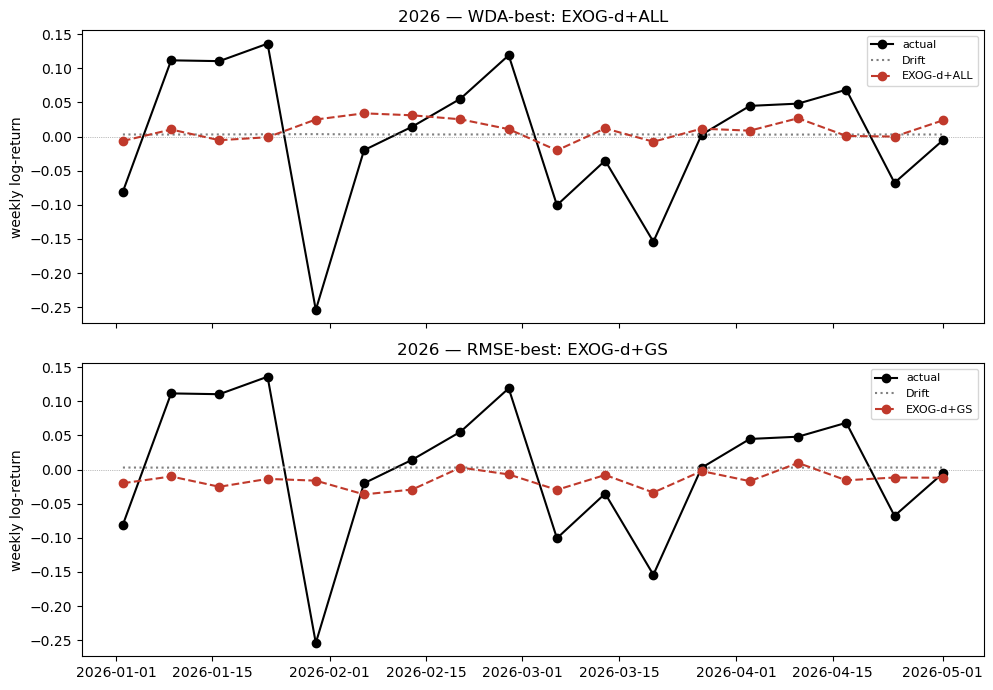

In [17]:
m26 = dates_te >= pd.Timestamp('2026-01-01')
if m26.any():
    drift_p = all_preds['Drift (prevailing mean)']
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for ax, (tag, bn) in zip(axes, [('WDA', best_wda), ('RMSE', best_rmse)]):
        bp = np.asarray(all_preds[bn])
        ax.axhline(0, color='grey', ls=':', lw=.5)
        ax.plot(dates_te[m26], np.asarray(y_te)[m26], 'k-o', label='actual')
        ax.plot(dates_te[m26], np.asarray(drift_p)[m26], ':', color='grey', label='Drift')
        ax.plot(dates_te[m26], bp[m26], '--o', color='#c0392b', label=bn)
        ax.set_title(f'2026 — {tag}-best: {bn}'); ax.set_ylabel('weekly log-return'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('No 2026 data in test set yet.')
